# Notebook 3 — Customer Segmentation (Rare, Frequent, Heavy)

**Goal:** Group customers into bundles based on how much they buy.

This notebook:
- Builds customer features from `orders` and `order_products__prior`
- Creates simple customer bundles: `rare`, `frequent`, `heavy`
- Summarizes each segment (orders, basket size, reorder rate, unique products)
- Compares product/department behavior across segments
- Prepares a clean segmentation table for the next notebooks

In [3]:
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def load_instacart_tables():
    """
    Load Instacart tables needed for segmentation.

    Returns
    -------
    dict
        Main tables used in this notebook.
    """
    tables = {
        "orders": pd.read_csv("../data/orders.csv"),
        "order_products__prior": pd.read_csv("../data/order_products__prior.csv"),
        "products": pd.read_csv("../data/products.csv"),
        "aisles": pd.read_csv("../data/aisles.csv"),
        "departments": pd.read_csv("../data/departments.csv"),
    }
    return tables


def enrich_products(products, aisles, departments):
    """
    Merge products with aisles and departments.

    Returns
    -------
    DataFrame
        Products with aisle and department names.
    """
    df = products.merge(aisles, on="aisle_id", how="left")
    df = df.merge(departments, on="department_id", how="left")
    return df


def build_user_features(orders, op_prior):
    """
    Build simple customer features for segmentation.

    Features
    --------
    - n_orders_total
    - n_prior_orders
    - n_items_prior
    - avg_basket_size_prior
    - reorder_rate_prior
    - n_unique_products_prior
    - n_unique_departments_prior
    - avg_days_since_prior_order (from orders)
    - most_common_order_dow
    - most_common_order_hour

    Returns
    -------
    DataFrame
        One row per user with segmentation features.
    """
    # Orders summary from the full orders table
    orders_user = orders.groupby("user_id").agg(
        n_orders_total=("order_id", "nunique"),
        avg_days_since_prior_order=("days_since_prior_order", "mean")
    ).reset_index()

    # Most common day/hour (behavior profile)
    dow_mode = orders.groupby("user_id")["order_dow"].agg(
        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan
    ).reset_index(name="most_common_order_dow")

    hour_mode = orders.groupby("user_id")["order_hour_of_day"].agg(
        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan
    ).reset_index(name="most_common_order_hour")

    # Keep only prior orders for transaction-based features
    prior_order_ids = set(op_prior["order_id"].unique())
    prior_orders = orders[orders["order_id"].isin(prior_order_ids)][["order_id", "user_id"]].copy()

    # Number of prior orders per user
    n_prior_orders = prior_orders.groupby("user_id")["order_id"].nunique().reset_index(name="n_prior_orders")

    # Basket size per prior order
    basket_sizes = op_prior.groupby("order_id").size().reset_index(name="basket_size")
    basket_sizes = basket_sizes.merge(prior_orders, on="order_id", how="left")

    basket_user = basket_sizes.groupby("user_id").agg(
        n_items_prior=("basket_size", "sum"),
        avg_basket_size_prior=("basket_size", "mean")
    ).reset_index()

    # Reorder rate per user (prior only)
    rr = op_prior.merge(prior_orders, on="order_id", how="left")
    reorder_rate = rr.groupby("user_id")["reordered"].mean().reset_index(name="reorder_rate_prior")

    # Unique products per user (prior only)
    unique_prod = rr.groupby("user_id")["product_id"].nunique().reset_index(name="n_unique_products_prior")

    # Merge all user features
    user_features = orders_user.merge(dow_mode, on="user_id", how="left")
    user_features = user_features.merge(hour_mode, on="user_id", how="left")
    user_features = user_features.merge(n_prior_orders, on="user_id", how="left")
    user_features = user_features.merge(basket_user, on="user_id", how="left")
    user_features = user_features.merge(reorder_rate, on="user_id", how="left")
    user_features = user_features.merge(unique_prod, on="user_id", how="left")

    # Fill missing values for users with no prior orders (rare but possible)
    fill_cols = [
        "n_prior_orders", "n_items_prior", "avg_basket_size_prior",
        "reorder_rate_prior", "n_unique_products_prior"
    ]
    user_features[fill_cols] = user_features[fill_cols].fillna(0)

    return user_features


def add_unique_departments_feature(user_features, orders, op_prior, products_enriched):
    """
    Add number of unique departments per user using prior purchases.

    Returns
    -------
    DataFrame
        User features with n_unique_departments_prior.
    """
    prior_order_ids = set(op_prior["order_id"].unique())
    prior_orders = orders[orders["order_id"].isin(prior_order_ids)][["order_id", "user_id"]].copy()

    tmp = op_prior.merge(prior_orders, on="order_id", how="left")
    tmp = tmp.merge(products_enriched[["product_id", "department"]], on="product_id", how="left")

    dep_count = tmp.groupby("user_id")["department"].nunique().reset_index(name="n_unique_departments_prior")

    df = user_features.merge(dep_count, on="user_id", how="left")
    df["n_unique_departments_prior"] = df["n_unique_departments_prior"].fillna(0)
    return df


def segment_users_quantiles(user_features, col="n_items_prior"):
    """
    Segment users into rare / frequent / heavy using quantiles.

    Parameters
    ----------
    user_features : DataFrame
        Customer feature table.
    col : str
        Column used for segmentation.

    Returns
    -------
    DataFrame
        User features with segment column.
    """
    df = user_features.copy()

    q1 = df[col].quantile(1/3)
    q2 = df[col].quantile(2/3)

    def assign_segment(x):
        if x <= q1:
            return "rare"
        elif x <= q2:
            return "frequent"
        else:
            return "heavy"

    df["segment"] = df[col].apply(assign_segment)
    return df


def segment_thresholds(user_features, col="n_items_prior"):
    """
    Return the quantile thresholds used for segmentation.

    Returns
    -------
    DataFrame
        q33 and q66 thresholds.
    """
    q1 = user_features[col].quantile(1/3)
    q2 = user_features[col].quantile(2/3)

    return pd.DataFrame([{
        "feature_used": col,
        "q33_threshold": q1,
        "q66_threshold": q2
    }])


def segment_counts(segmented_users):
    """
    Count users in each segment.

    Returns
    -------
    DataFrame
        Number and percentage of users by segment.
    """
    counts = segmented_users["segment"].value_counts().reset_index()
    counts.columns = ["segment", "n_users"]
    counts["pct_users"] = counts["n_users"] / counts["n_users"].sum()
    return counts


def segment_summary(segmented_users):
    """
    Create summary statistics per segment.

    Returns
    -------
    DataFrame
        Segment-level averages.
    """
    summary = segmented_users.groupby("segment").agg(
        n_users=("user_id", "nunique"),
        avg_n_orders_total=("n_orders_total", "mean"),
        avg_n_prior_orders=("n_prior_orders", "mean"),
        avg_n_items_prior=("n_items_prior", "mean"),
        avg_basket_size_prior=("avg_basket_size_prior", "mean"),
        avg_reorder_rate_prior=("reorder_rate_prior", "mean"),
        avg_unique_products_prior=("n_unique_products_prior", "mean"),
        avg_unique_departments_prior=("n_unique_departments_prior", "mean"),
        avg_days_since_prior_order=("avg_days_since_prior_order", "mean"),
    ).reset_index()

    # Keep a logical segment order
    order_map = {"rare": 0, "frequent": 1, "heavy": 2}
    summary["sort_key"] = summary["segment"].map(order_map)
    summary = summary.sort_values("sort_key").drop(columns="sort_key")
    return summary


def plot_segment_counts(segmented_users):
    """
    Plot number of users in each segment.
    """
    counts = segment_counts(segmented_users)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=counts, x="segment", y="n_users")
    plt.title("Customer segments (number of users)")
    plt.xlabel("segment")
    plt.ylabel("number of users")
    plt.show()


def plot_feature_by_segment(segmented_users, feature_col, title):
    """
    Plot a boxplot of one feature by segment.

    Parameters
    ----------
    segmented_users : DataFrame
        User segmentation table.
    feature_col : str
        Feature to plot.
    title : str
        Plot title.
    """
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=segmented_users, x="segment", y=feature_col, order=["rare", "frequent", "heavy"])
    plt.title(title)
    plt.xlabel("segment")
    plt.ylabel(feature_col)
    plt.show()


def attach_segment_to_prior_lines(segmented_users, orders, op_prior):
    """
    Add customer segment to each prior purchase line.

    Returns
    -------
    DataFrame
        Prior purchase lines with user_id and segment.
    """
    prior_order_ids = set(op_prior["order_id"].unique())
    prior_orders = orders[orders["order_id"].isin(prior_order_ids)][["order_id", "user_id"]].copy()

    tmp = op_prior.merge(prior_orders, on="order_id", how="left")
    tmp = tmp.merge(segmented_users[["user_id", "segment"]], on="user_id", how="left")
    return tmp


def segment_department_distribution(prior_lines_with_segment, products_enriched):
    """
    Compare department distribution across customer segments.

    Returns
    -------
    DataFrame
        Department share by segment.
    """
    tmp = prior_lines_with_segment.merge(
        products_enriched[["product_id", "department"]],
        on="product_id",
        how="left"
    )

    dep = tmp.groupby(["segment", "department"]).size().reset_index(name="n_lines")
    dep["share_in_segment"] = dep.groupby("segment")["n_lines"].transform(lambda x: x / x.sum())

    # Sort for readability
    dep = dep.sort_values(["segment", "n_lines"], ascending=[True, False])
    return dep


def segment_top_products(prior_lines_with_segment, products_enriched, top_n=10):
    """
    Get top purchased products for each segment.

    Returns
    -------
    DataFrame
        Top products by segment.
    """
    tmp = prior_lines_with_segment.merge(
        products_enriched[["product_id", "product_name", "department", "aisle"]],
        on="product_id",
        how="left"
    )

    prod = tmp.groupby(["segment", "product_id", "product_name", "department", "aisle"]).size().reset_index(name="n_purchases")

    # Rank inside each segment
    prod["rank_in_segment"] = prod.groupby("segment")["n_purchases"].rank(method="first", ascending=False)
    prod = prod[prod["rank_in_segment"] <= top_n].copy()

    prod = prod.sort_values(["segment", "rank_in_segment"])
    return prod


def save_segmentation_table(segmented_users, file_name="segmented_users.csv"):
    """
    Save the segmentation table for later notebooks.

    Parameters
    ----------
    segmented_users : DataFrame
        Final user segmentation table.
    file_name : str
        Output CSV file name.
    """
    segmented_users.to_csv(file_name, index=False)


In [5]:
# Load data
tables = load_instacart_tables()

orders = tables["orders"]
op_prior = tables["order_products__prior"]
products = tables["products"]
aisles = tables["aisles"]
departments = tables["departments"]

products_enriched = enrich_products(products, aisles, departments)

In [6]:
# 1) Build customer features
user_features = build_user_features(orders, op_prior)
user_features = add_unique_departments_feature(user_features, orders, op_prior, products_enriched)

display(user_features.head())
display(user_features.describe())

,user_id,n_orders_total,avg_days_since_prior_order,most_common_order_dow,most_common_order_hour,n_prior_orders,n_items_prior,avg_basket_size_prior,reorder_rate_prior,n_unique_products_prior,n_unique_departments_prior
0,1,11,19.000000,4,7,10,59,5.900000,0.694915,18,7
1,2,15,16.285714,1,10,14,195,13.928571,0.476923,102,13
2,3,13,12.000000,0,16,12,88,7.333333,0.625000,33,9
3,4,6,17.000000,4,11,5,18,3.600000,0.055556,17,9
4,5,5,11.500000,0,18,4,37,9.250000,0.378378,23,9


,user_id,n_orders_total,avg_days_since_prior_order,most_common_order_dow,most_common_order_hour,n_prior_orders,n_items_prior,avg_basket_size_prior,reorder_rate_prior,n_unique_products_prior,n_unique_departments_prior
count,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000
mean,103105.000000,16.590367,15.448686,2.116430,12.310059,15.590367,157.289396,9.951586,0.432249,64.536238,10.827796
std,59527.555167,16.654774,6.915575,2.080834,3.989229,16.654774,204.208233,5.863570,0.212144,56.592339,3.791768
min,1.000000,4.000000,0.000000,0.000000,0.000000,3.000000,3.000000,1.000000,0.000000,1.000000,1.000000
25%,51553.000000,6.000000,9.814815,0.000000,9.000000,5.000000,39.000000,5.740741,0.267857,25.000000,8.000000
50%,103105.000000,10.000000,15.000000,1.000000,12.000000,9.000000,83.000000,8.933333,0.428571,48.000000,11.000000
75%,154657.000000,20.000000,20.625000,4.000000,15.000000,19.000000,188.000000,13.000000,0.595745,86.000000,14.000000
max,206209.000000,100.000000,30.000000,6.000000,23.000000,99.000000,3725.000000,70.250000,0.989529,726.000000,21.000000


In [7]:
# 2) Create segments (rare / frequent / heavy)
display(segment_thresholds(user_features, col="n_items_prior"))

segmented_users = segment_users_quantiles(user_features, col="n_items_prior")

display(segment_counts(segmented_users))
display(segment_summary(segmented_users))

,feature_used,q33_threshold,q66_threshold
0,n_items_prior,51.0,140.0


,segment,n_users,pct_users
0,rare,69600,0.337522
1,heavy,68392,0.331664
2,frequent,68217,0.330815


,segment,n_users,avg_n_orders_total,avg_n_prior_orders,avg_n_items_prior,avg_basket_size_prior,avg_reorder_rate_prior,avg_unique_products_prior,avg_unique_departments_prior,avg_days_since_prior_order
2,rare,69600,6.505345,5.505345,28.690000,6.138613,0.292776,20.179037,7.295675,19.026931
0,frequent,68217,11.564551,10.564551,87.809095,10.646962,0.402607,51.338391,11.268936,16.264798
1,heavy,68392,31.866476,30.866476,357.462744,13.138311,0.603752,122.840990,13.982293,10.993216


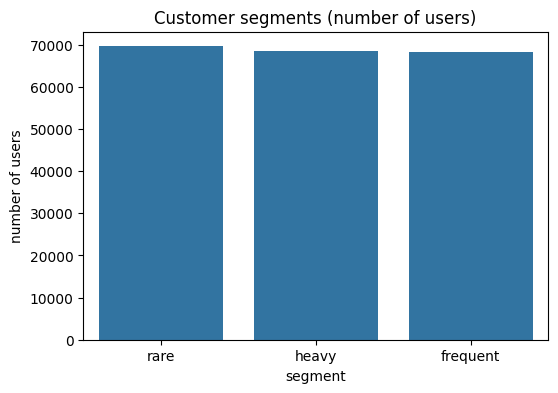

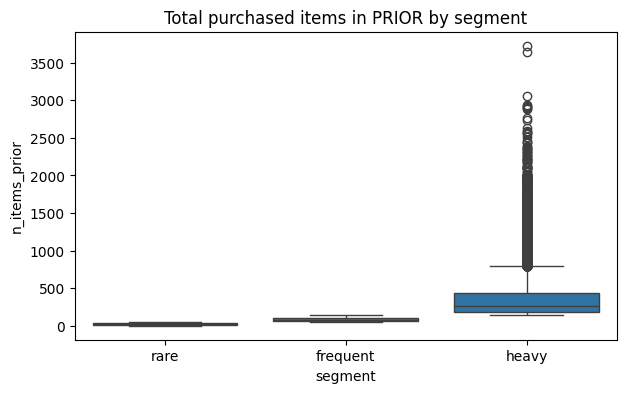

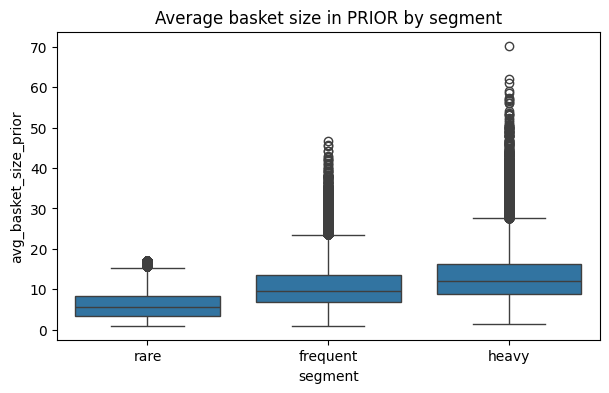

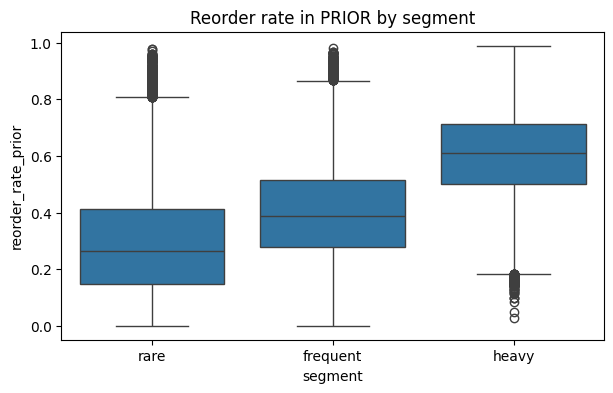

In [ ]:
# 3) Plot segment distributions and key features
plot_segment_counts(segmented_users)

plot_feature_by_segment(segmented_users, "n_items_prior", "Total purchased items in PRIOR by segment")
plot_feature_by_segment(segmented_users, "avg_basket_size_prior", "Average basket size in PRIOR by segment")
plot_feature_by_segment(segmented_users, "reorder_rate_prior", "Reorder rate in PRIOR by segment")

In [9]:
# 4) Attach segments to prior purchase lines
prior_lines_segmented = attach_segment_to_prior_lines(segmented_users, orders, op_prior)
display(prior_lines_segmented.head())

,order_id,product_id,add_to_cart_order,reordered,user_id,segment
0,2,33120,1,1,202279,frequent
1,2,28985,2,1,202279,frequent
2,2,9327,3,0,202279,frequent
3,2,45918,4,1,202279,frequent
4,2,30035,5,0,202279,frequent


,segment,department,n_lines,share_in_segment
19,frequent,produce,1686143,0.281490
7,frequent,dairy eggs,943630,0.157532
3,frequent,beverages,533881,0.089128
20,frequent,snacks,520055,0.086819
10,frequent,frozen,446176,0.074486
16,frequent,pantry,368963,0.061596
2,frequent,bakery,210833,0.035197
6,frequent,canned goods,206636,0.034496
8,frequent,deli,191220,0.031923
9,frequent,dry goods pasta,165117,0.027565


,segment,department,n_lines,share_in_segment,rank_in_segment
19,frequent,produce,1686143,0.281490,1.0
7,frequent,dairy eggs,943630,0.157532,2.0
3,frequent,beverages,533881,0.089128,3.0
20,frequent,snacks,520055,0.086819,4.0
10,frequent,frozen,446176,0.074486,5.0
16,frequent,pantry,368963,0.061596,6.0
2,frequent,bakery,210833,0.035197,7.0
6,frequent,canned goods,206636,0.034496,8.0
8,frequent,deli,191220,0.031923,9.0
9,frequent,dry goods pasta,165117,0.027565,10.0


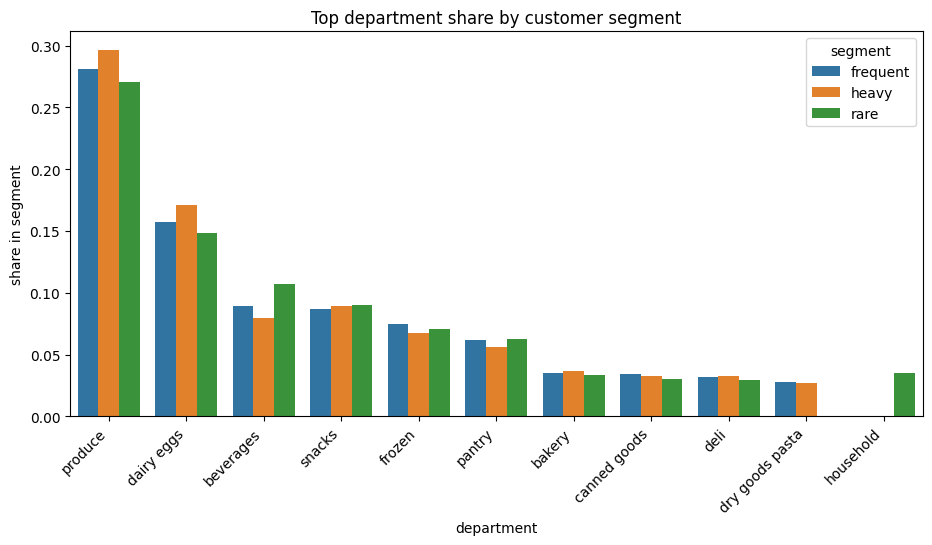

In [10]:
# 5) Compare department behavior by segment
dep_by_segment = segment_department_distribution(prior_lines_segmented, products_enriched)
display(dep_by_segment.head(30))

# Top departments per segment (compact table)
top_dep = dep_by_segment.copy()
top_dep["rank_in_segment"] = top_dep.groupby("segment")["n_lines"].rank(method="first", ascending=False)
top_dep = top_dep[top_dep["rank_in_segment"] <= 10].sort_values(["segment", "rank_in_segment"])
display(top_dep)

# Plot top department shares
plt.figure(figsize=(11, 5))
sns.barplot(data=top_dep, x="department", y="share_in_segment", hue="segment")
plt.title("Top department share by customer segment")
plt.xlabel("department")
plt.ylabel("share in segment")
plt.xticks(rotation=45, ha="right")
plt.show()

In [11]:
# 6) Top products by segment
top_products_by_segment = segment_top_products(prior_lines_segmented, products_enriched, top_n=10)
display(top_products_by_segment)

,segment,product_id,product_name,department,aisle,n_purchases,rank_in_segment
23728,frequent,24852,Banana,produce,fresh fruits,85103,1.0
12590,frequent,13176,Bag of Organic Bananas,produce,fresh fruits,64217,2.0
20911,frequent,21903,Organic Baby Spinach,produce,packaged vegetables fruits,42606,3.0
20175,frequent,21137,Organic Strawberries,produce,fresh fruits,38795,4.0
45524,frequent,47766,Organic Avocado,produce,fresh fruits,33960,5.0
16035,frequent,16797,Strawberries,produce,fresh fruits,30518,6.0
44988,frequent,47209,Organic Hass Avocado,produce,fresh fruits,29706,7.0
45389,frequent,47626,Large Lemon,produce,fresh fruits,29402,8.0
25029,frequent,26209,Limes,produce,fresh fruits,23949,9.0
26572,frequent,27845,Organic Whole Milk,dairy eggs,milk,19835,10.0


In [13]:
# 7) Save segmentation output for next notebooks (basket building / rules / evaluation)
save_segmentation_table(segmented_users, file_name="../outputs/segmented_users.csv")